# Unit 2 | NLP 03 — Text Classification: Broad Method Overview

A side-by-side comparison of four classification approaches applied to the same dataset with identical evaluation for each. Every method section follows the same structure: train/predict → accuracy + macro F1 → classification report → confusion matrix.

| # | Method | Needs labels? | Features |
|---|---|---|---|
| 1 | Logistic Regression | ✓ | TF-IDF |
| 2 | Logistic Regression | ✓ | Sentence Embeddings |
| 3 | Ollama LLM | ✗ | Raw text |
| 4 | Distillation | Pseudo only | Sentence Embeddings |

Methods 3 & 4 each run once per local model (`llama3.2:3b`, `gpt-oss:20b`), so the leaderboard shows two LLM rows and two distillation rows.

**Dataset:** arXiv metadata snapshot (Kaggle) — Computer Science · Astrophysics · Mathematics · Quantitative Biology · Statistics

In [1]:
import warnings
warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sentence_transformers import SentenceTransformer
import ollama

pd.set_option('display.max_columns', 100)
plt.style.use('dark_background')

In [2]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
ARXIV_PATH          = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/arXiv/arxiv-metadata-oai-snapshot.json'
ARXIV_CATEGORIES    = ['cs', 'astro-ph', 'math', 'q-bio', 'stat']   # top-level archives = classes
PAPERS_PER_CATEGORY = 500        # papers per class; split 80/20 into train/test
CHUNK_SIZE          = 50_000     # number of JSON-lines to read per chunk

RANDOM_STATE = 42
MAX_FEATURES = 10000
EMB_MODEL    = 'all-MiniLM-L6-v2'
OLLAMA_MODELS = ['llama3.2:3b-instruct-q5_K_M', 'gpt-oss:20b']  # compared head-to-head in Methods 3 & 4

# How many test papers per class the LLM will label.
# Those same labeled papers are used to train the distilled classifier in Method 4.
# Increase for better distillation quality; decrease to speed up the LLM step.
SAMPLES_PER_CLASS = 20
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
def primary_archive(categories_str):
    """Return the top-level arXiv archive from the primary (first-listed) category.

    'stat.ML cs.LG'  →  'stat'
    'astro-ph.GA'    →  'astro-ph'
    """
    first_code = str(categories_str).split()[0]
    return first_code.split('.')[0]

keep_cols = ['title', 'abstract', 'categories']
pieces = {cat: [] for cat in ARXIV_CATEGORIES}   # collected rows per class
counts = {cat: 0  for cat in ARXIV_CATEGORIES}   # how many we have so far

print('Streaming arXiv metadata until each class is full...')
print(f'  Target: {PAPERS_PER_CATEGORY} papers per class')
for chunk in pd.read_json(ARXIV_PATH, lines=True, chunksize=CHUNK_SIZE):
    chunk = chunk[keep_cols].copy()

    # Label each paper by the top level of its primary (first-listed) category.
    chunk['archive'] = chunk['categories'].map(primary_archive)

    # Keep only papers whose primary archive is one we care about.
    chunk = chunk[chunk['archive'].isin(ARXIV_CATEGORIES)]

    # Filter to abstracts of reasonable length (50–300 words).
    word_count = chunk['abstract'].fillna('').str.split().str.len()
    chunk = chunk[(word_count >= 50) & (word_count <= 300)]

    # Accumulate rows for each class until it is full.
    for cat in ARXIV_CATEGORIES:
        if counts[cat] < PAPERS_PER_CATEGORY:
            still_needed = PAPERS_PER_CATEGORY - counts[cat]
            new_rows = chunk[chunk['archive'] == cat].head(still_needed)
            pieces[cat].append(new_rows)
            counts[cat] += len(new_rows)

    # Stop reading once every class has enough papers.
    if all(counts[cat] >= PAPERS_PER_CATEGORY for cat in ARXIV_CATEGORIES):
        break

# If a rare class never reached PAPERS_PER_CATEGORY, we use what was found.
df = pd.concat([pd.concat(pieces[cat]) for cat in ARXIV_CATEGORIES], ignore_index=True)
print('\nPapers loaded per class:')
print(df['archive'].value_counts())

Streaming arXiv metadata until each class is full...
  Target: 500 papers per class

Papers loaded per class:
archive
cs          500
astro-ph    500
math        500
q-bio       500
stat        500
Name: count, dtype: int64


In [4]:
# ── Readable category names ───────────────────────────────────────────────────
KEY2TOPIC = {
    'cs':       'Computer Science',
    'astro-ph': 'Astrophysics',
    'math':     'Mathematics',
    'q-bio':    'Quantitative Biology',
    'stat':     'Statistics',
}
# category_names[i] is the human-readable label for integer class i.
category_names = [KEY2TOPIC[cat] for cat in ARXIV_CATEGORIES]

# ── Build text and integer label columns ─────────────────────────────────────
df['text']  = df['title'].str.strip() + '\n' + df['abstract'].str.strip()
df['label'] = df['archive'].map(lambda a: ARXIV_CATEGORIES.index(a))

# ── Stratified 80/20 train/test split ────────────────────────────────────────
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=RANDOM_STATE
)
train_texts  = train_df['text'].tolist()
train_labels = train_df['label'].to_numpy()
test_texts   = test_df['text'].tolist()
test_labels  = test_df['label'].to_numpy()

print(f'Train: {len(train_texts):,} papers   Test: {len(test_texts):,} papers')
print(f'Classes: {category_names}')

Train: 2,000 papers   Test: 500 papers
Classes: ['Computer Science', 'Astrophysics', 'Mathematics', 'Quantitative Biology', 'Statistics']


## Setup — Data & Feature Preparation

All representations are computed once up front so that method sections only measure fit+predict time.

- **TF-IDF** (10,000 features, sublinear TF) — fit on training split only
- **Sentence Embeddings** (`all-MiniLM-L6-v2`, 384-d) — encoded once, cached in memory
- **t-SNE** — 2-D projection of test embeddings as a visual sanity check before classification

Fitting TfidfVectorizer... done  (10,000 features)

Encoding with all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Embeddings: train=(2000, 384)  test=(500, 384)

Projecting with t-SNE...


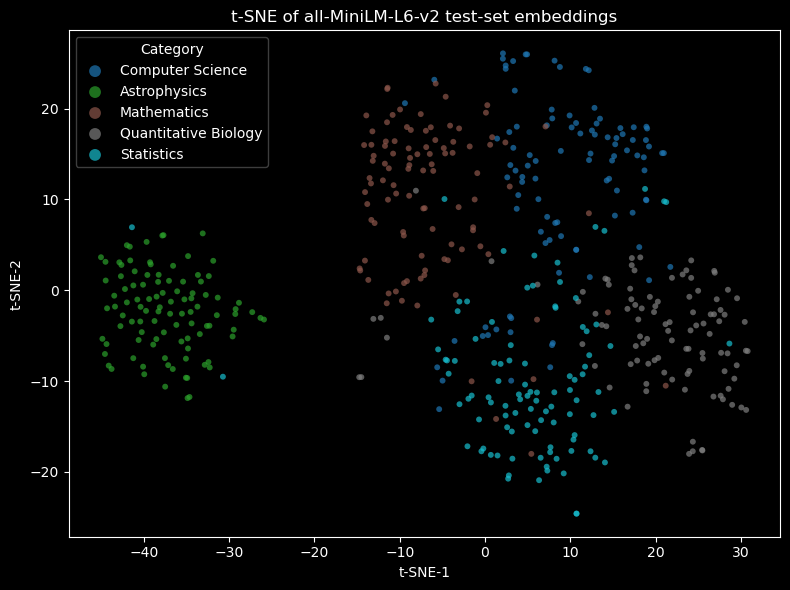

In [5]:
# ── TF-IDF ───────────────────────────────────────────────────────────────────
print('Fitting TfidfVectorizer...', end=' ', flush=True)
tfidf = TfidfVectorizer(max_features=MAX_FEATURES, stop_words='english', sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf  = tfidf.transform(test_texts)
print(f'done  ({X_train_tfidf.shape[1]:,} features)')

# ── Sentence Embeddings ───────────────────────────────────────────────────────
print(f'\nEncoding with {EMB_MODEL}...')
emb_model   = SentenceTransformer(EMB_MODEL)
X_train_emb = emb_model.encode(train_texts, show_progress_bar=True, batch_size=64)
X_test_emb  = emb_model.encode(test_texts,  show_progress_bar=True, batch_size=64)
print(f'Embeddings: train={X_train_emb.shape}  test={X_test_emb.shape}')

# ── t-SNE — embedding structure before any classification ─────────────────────
print('\nProjecting with t-SNE...')
reducer = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
coords  = reducer.fit_transform(X_test_emb)

palette = plt.cm.get_cmap('tab10', len(category_names))
fig, ax = plt.subplots(figsize=(8, 6))
for i, cat in enumerate(category_names):
    mask = test_labels == i
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=palette(i), label=cat, alpha=0.7, s=18, edgecolors='none')
ax.legend(title='Category', markerscale=2, framealpha=0.3)
ax.set_title(f't-SNE of {EMB_MODEL} test-set embeddings')
ax.set_xlabel('t-SNE-1'); ax.set_ylabel('t-SNE-2')
plt.tight_layout(); plt.show()

In [6]:
results = []   # accumulates per-method dicts for the final leaderboard

def evaluate(name, y_true, y_pred):
    """Identical analysis block applied to every method in this notebook."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')

    print(f'Accuracy : {acc:.4f}')
    print(f'Macro F1 : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=category_names))

    fig, ax = plt.subplots(figsize=(6, 5.5))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', square=True,
                xticklabels=category_names, yticklabels=category_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(name)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    results.append({'Method': name, 'Accuracy': round(acc, 4), 'Macro F1': round(f1, 4)})

## 1 · Logistic Regression — TF-IDF

A linear model that estimates class probabilities via the logistic function. Fast, interpretable via per-class coefficients, and often surprisingly competitive on text — a strong first baseline before trying anything heavier.

Accuracy : 0.8880
Macro F1 : 0.8878

                      precision    recall  f1-score   support

    Computer Science       0.82      0.85      0.83       100
        Astrophysics       0.99      1.00      1.00       100
         Mathematics       0.89      0.87      0.88       100
Quantitative Biology       0.90      0.91      0.91       100
          Statistics       0.84      0.81      0.83       100

            accuracy                           0.89       500
           macro avg       0.89      0.89      0.89       500
        weighted avg       0.89      0.89      0.89       500



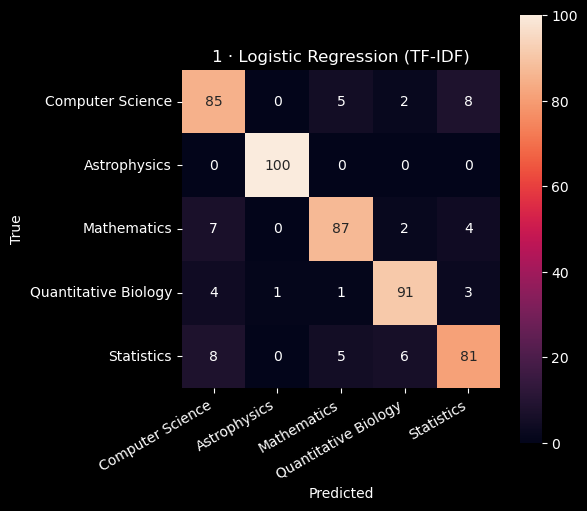

In [7]:
lr_tfidf = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
lr_tfidf.fit(X_train_tfidf, train_labels)
y_pred_lr = lr_tfidf.predict(X_test_tfidf)
evaluate('1 · Logistic Regression (TF-IDF)', test_labels, y_pred_lr)

## 2 · Logistic Regression — Sentence Embeddings

`all-MiniLM-L6-v2` encodes each post as a 384-d dense vector capturing semantic meaning. A Logistic Regression head separates classes in that embedding space rather than in vocabulary space — generalizing better to paraphrases and unseen words.

Accuracy : 0.9180
Macro F1 : 0.9179

                      precision    recall  f1-score   support

    Computer Science       0.85      0.91      0.88       100
        Astrophysics       0.99      1.00      1.00       100
         Mathematics       0.96      0.87      0.91       100
Quantitative Biology       0.93      0.96      0.95       100
          Statistics       0.87      0.85      0.86       100

            accuracy                           0.92       500
           macro avg       0.92      0.92      0.92       500
        weighted avg       0.92      0.92      0.92       500



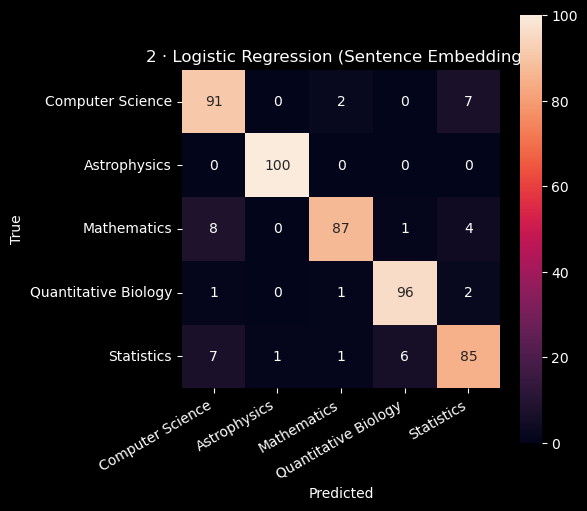

In [8]:
lr_emb = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
lr_emb.fit(X_train_emb, train_labels)
y_pred_lr_emb = lr_emb.predict(X_test_emb)
evaluate('2 · Logistic Regression (Sentence Embeddings)', test_labels, y_pred_lr_emb)

## 3 · LLM Classification — Ollama + JSON Schema

A locally-running LLM receives each paper abstract and returns a prediction constrained by a JSON Schema. **No training data** — the model reasons from pre-training knowledge about what each category means. The same stratified sample is classified by each model so the comparison is fair.

Evaluated on a stratified sample (full set would take ~10 min on CPU per model).

Requires:
```
ollama pull llama3.2:3b-instruct-q5_K_M
ollama pull gpt-oss:20b
```


Classifying 100 papers with llama3.2:3b-instruct-q5_K_M (20 per class)...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100
Accuracy : 0.7100
Macro F1 : 0.6937

                      precision    recall  f1-score   support

    Computer Science       0.57      0.85      0.68        20
        Astrophysics       0.86      0.95      0.90        20
         Mathematics       0.64      0.90      0.75        20
Quantitative Biology       0.75      0.45      0.56        20
          Statistics       1.00      0.40      0.57        20

            accuracy                           0.71       100
           macro avg       0.76      0.71      0.69       100
        weighted avg       0.76      0.71      0.69       100



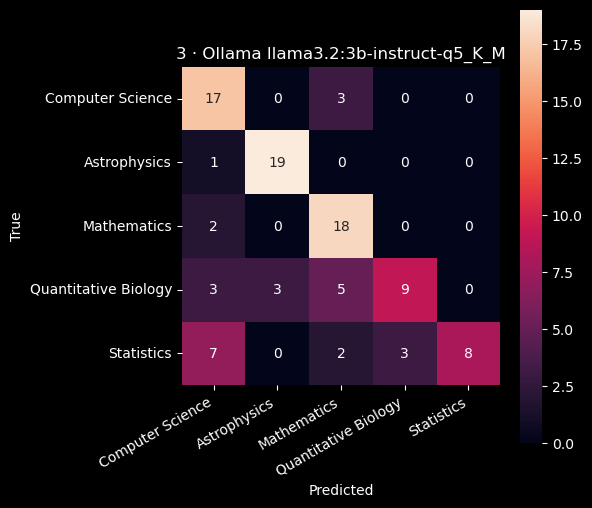

  Unloading llama3.2:3b-instruct-q5_K_M from RAM...

Classifying 100 papers with gpt-oss:20b (20 per class)...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100
Accuracy : 0.8800
Macro F1 : 0.8775

                      precision    recall  f1-score   support

    Computer Science       0.76      0.95      0.84        20
        Astrophysics       1.00      1.00      1.00        20
         Mathematics       0.90      0.90      0.90        20
Quantitative Biology       0.90      0.90      0.90        20
          Statistics       0.87      0.65      0.74        20

            accuracy                           0.88       100
           macro avg       0.89      0.88      0.88       100
        weighted avg       0.89      0.88      0.88       100



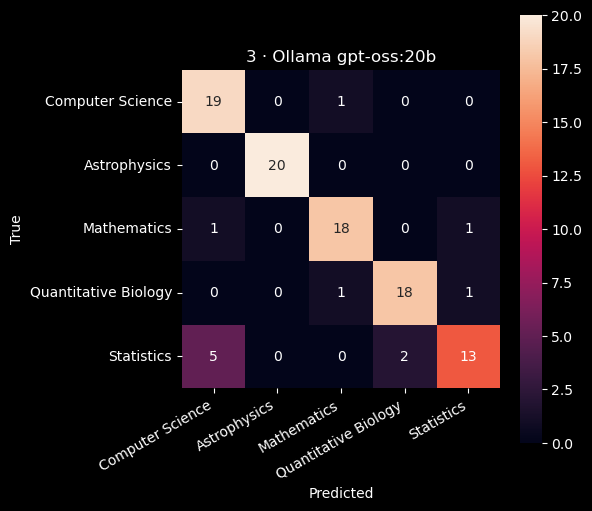

  Unloading gpt-oss:20b from RAM...


In [10]:
CAT_SCHEMA = {
    'type': 'object',
    'properties': {
        'category': {
            'type': 'string',
            'enum': category_names,
            'description': 'The single arXiv archive category that best describes this paper.',
        }
    },
    'required': ['category'],
    'additionalProperties': False,
}

SYSTEM_MSG = (
    'You are an arXiv paper classifier. '
    'Return the single category that best describes the given paper abstract. '
    f"Choose exactly one of: {', '.join(category_names)}."
)

# --- Stratified sampling: SAMPLES_PER_CLASS papers per category ---
# The SAME sample is used for every model so the comparison is fair.
# These labeled papers also become the distillation training set in Method 4.
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = []
for class_id in range(len(category_names)):
    positions_in_class = [i for i in range(len(test_labels)) if test_labels[i] == class_id]
    n_to_label = min(SAMPLES_PER_CLASS, len(positions_in_class))
    chosen = rng.choice(positions_in_class, size=n_to_label, replace=False)
    sample_idx.extend(chosen)

y_sample = test_labels[sample_idx]


def classify_with_ollama(model_name):
    """Classify each sampled abstract with one Ollama model; return integer predictions."""
    preds = []
    for i, idx in enumerate(sample_idx):
        resp = ollama.chat(
            model=model_name,
            messages=[
                {'role': 'system', 'content': SYSTEM_MSG},
                {'role': 'user',   'content': f'Abstract:\n{test_texts[idx][:1200]}'},
            ],
            format=CAT_SCHEMA,
            options={'temperature': 0},
        )
        try:
            cat  = json.loads(resp['message']['content'])['category']
            pred = category_names.index(cat)
        except Exception:
            pred = 0   # fallback to class 0 if the LLM returns an unexpected response
        preds.append(pred)
        if (i + 1) % 10 == 0:
            print(f'  {i+1}/{len(sample_idx)}')
    return np.array(preds)


# Run every configured model over the SAME sampled papers and store its predictions.
ollama_preds_by_model = {}
for model_name in OLLAMA_MODELS:
    print(f'\nClassifying {len(sample_idx)} papers with {model_name} '
          f'({SAMPLES_PER_CLASS} per class)...')
    preds = classify_with_ollama(model_name)
    ollama_preds_by_model[model_name] = preds
    evaluate(f'3 · Ollama {model_name}', y_sample, preds)

    # Force Ollama to evict this model from RAM before the next model loads.
    print(f'  Unloading {model_name} from RAM...')
    ollama.generate(model=model_name, prompt='', keep_alive=0)

## 4 · Distillation — LLM as Pseudo-Labeler

Use the Ollama predictions above as **noisy training labels** for a Logistic Regression on top of sentence embeddings. At inference time the LLM is no longer needed — the distilled model runs in milliseconds.

One distilled LogReg is trained per LLM teacher, showing how the quality of the teacher's pseudo-labels propagates to the student: a more accurate LLM produces better training signal and, in turn, a stronger distilled classifier.

Demonstrates how an LLM's zero-shot knowledge can bootstrap a fast deployed classifier when no gold labels exist.

Accuracy : 0.7050
Macro F1 : 0.6829

                      precision    recall  f1-score   support

    Computer Science       0.56      0.84      0.67        80
        Astrophysics       0.87      1.00      0.93        80
         Mathematics       0.66      0.91      0.76        80
Quantitative Biology       0.65      0.35      0.46        80
          Statistics       0.97      0.42      0.59        80

            accuracy                           0.70       400
           macro avg       0.74      0.70      0.68       400
        weighted avg       0.74      0.70      0.68       400



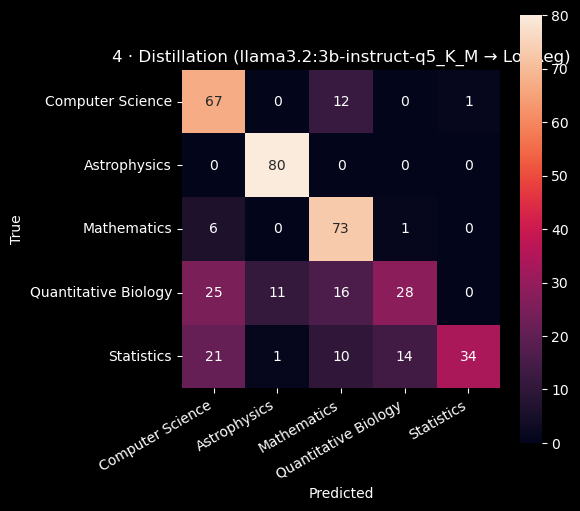

Accuracy : 0.8775
Macro F1 : 0.8776

                      precision    recall  f1-score   support

    Computer Science       0.74      0.93      0.82        80
        Astrophysics       0.98      1.00      0.99        80
         Mathematics       0.92      0.84      0.88        80
Quantitative Biology       0.91      0.88      0.89        80
          Statistics       0.88      0.75      0.81        80

            accuracy                           0.88       400
           macro avg       0.88      0.88      0.88       400
        weighted avg       0.88      0.88      0.88       400



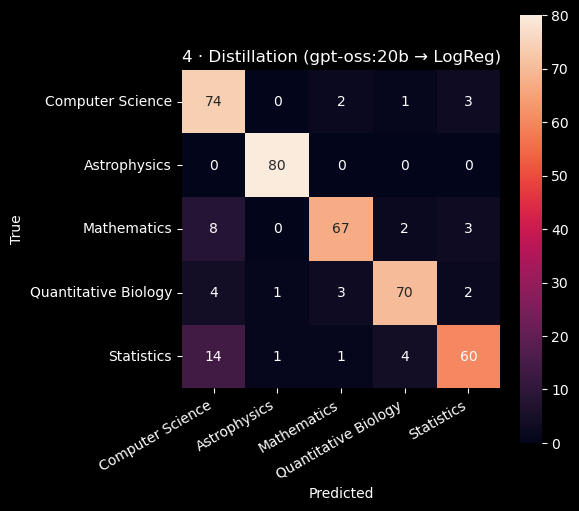

In [11]:
# The LLMs labeled `sample_idx` papers; the rest of the test set is held out for evaluation.
labeled_positions = sample_idx
labeled_set       = set(labeled_positions)
heldout_positions = [i for i in range(len(test_labels)) if i not in labeled_set]

# Scale embeddings once — the same labeled set and scaler feed every teacher.
scaler    = StandardScaler()
X_labeled = scaler.fit_transform(X_test_emb[labeled_positions])
X_heldout = scaler.transform(X_test_emb[heldout_positions])
y_heldout = test_labels[heldout_positions]

# Distill a fast LogReg from each LLM's noisy pseudo-labels.
# Better teacher -> better pseudo-labels -> better student.
for model_name in OLLAMA_MODELS:
    pseudo_labels   = ollama_preds_by_model[model_name]
    distilled_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    distilled_model.fit(X_labeled, pseudo_labels)
    y_pred_dist = distilled_model.predict(X_heldout)
    evaluate(f'4 · Distillation ({model_name} → LogReg)', y_heldout, y_pred_dist)

## Leaderboard

All methods ranked by Macro F1. Note that Ollama runs on a stratified sample and Distillation evaluates on the remaining test papers — their eval-n differs from the full test set.

,Method,Accuracy,Macro F1
1,2 · Logistic Regression (Sentence Embeddings),0.9180,0.9179
2,1 · Logistic Regression (TF-IDF),0.8880,0.8878
3,4 · Distillation (gpt-oss:20b → LogReg),0.8775,0.8776
4,3 · Ollama gpt-oss:20b,0.8800,0.8775
5,3 · Ollama llama3.2:3b-instruct-q5_K_M,0.7100,0.6937
6,4 · Distillation (llama3.2:3b-instruct-q5_K_M ...,0.7050,0.6829


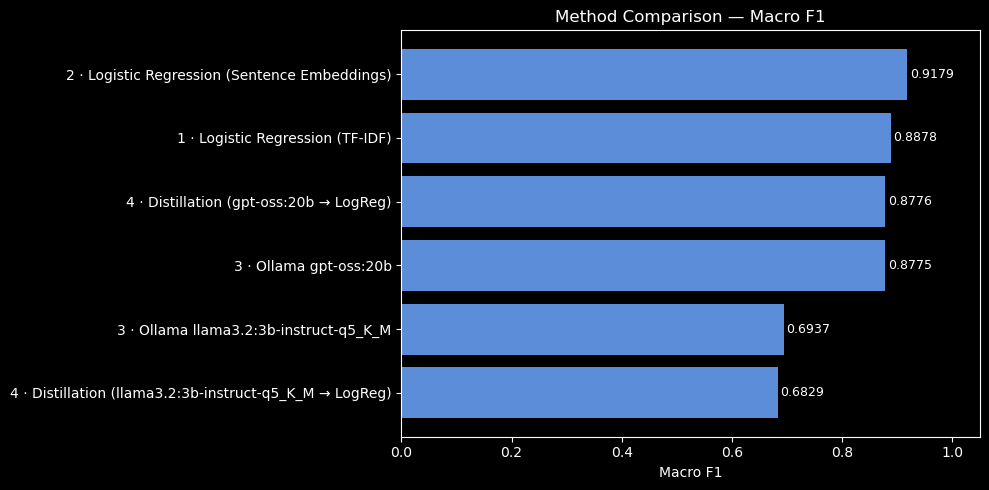

In [12]:
# Build the summary table (best F1 first) and display it.
lb = pd.DataFrame(results)
lb = lb.sort_values('Macro F1', ascending=False).reset_index(drop=True)
lb.index += 1   # 1-based row numbers for the table
display(lb)

# For the horizontal bar chart, sort ascending so the best method lands on top.
# (barh plots bars from bottom to top, so the last row appears highest.)
lb_chart = lb.sort_values('Macro F1', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(lb_chart['Method'], lb_chart['Macro F1'], color='#5b8dd9')
ax.set_xlabel('Macro F1')
ax.set_title('Method Comparison — Macro F1')
ax.set_xlim(0, 1.05)

# Label each bar with its exact F1 score.
for bar_position in range(len(lb_chart)):
    f1_val = lb_chart.loc[bar_position, 'Macro F1']
    ax.text(f1_val + 0.005, bar_position, f'{f1_val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()